# Compare surface winds with 100m

We want to establish if surface winds in climate models can be used directly or whether extrapolation to hub-height is necessary.

In [77]:
client.close()
cluster.close()

INFO:dask_jobqueue.pbs:Resource specification for PBS not set, initializing it to select=1:ncpus=24:mem=90GB


In [78]:
from dask.distributed import Client,LocalCluster
from dask_jobqueue import PBSCluster

In [79]:
PROJECT = "dt6"

In [80]:
walltime = "00:40:00"
cores = 24
memory = str(4 * cores) + "GB"

cluster = PBSCluster(
    walltime=str(walltime),
    cores=cores,
    memory=str(memory),
    processes=cores,
    job_extra_directives=[
        "-q normal",
        "-P "+PROJECT,
        "-l ncpus="+str(cores),
        "-l mem="+str(memory),
        "-l storage=gdata/xp65+gdata/ob53+gdata/w42+scratch/w42+gdata/gb02+scratch/gb02+gdata/ng72+scratch/ng72+gdata/rt52"
    ],
    local_directory="$TMPDIR",
    job_directives_skip=["select"],
    log_directory="/scratch/w42/dr6273/tmp/logs"
)

INFO:dask_jobqueue.pbs:Resource specification for PBS not set, initializing it to select=1:ncpus=24:mem=90GB
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38565 instead
  warnings.warn(


In [81]:
cluster.scale(jobs=1)
client = Client(cluster)

INFO:dask_jobqueue.pbs:Resource specification for PBS not set, initializing it to select=1:ncpus=24:mem=90GB


In [82]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /proxy/38565/status,
Dashboard: /proxy/38565/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.6.122.61:38081,Workers: 0
Dashboard: /proxy/38565/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [34]:
import xarray as xr

import glob

import matplotlib.pyplot as plt

In [30]:
%cd /g/data/w42/dr6273/work/wind_drought/
import functions as fn

%load_ext autoreload
%autoreload 2

/g/data/w42/dr6273/work/wind_drought
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
FILEPATH = "/g/data/ng72/dr6273/work/projects/wind_drought/data/"

In [10]:
YEARS = slice("1979", "2024")

### Load data

ERA5

In [11]:
era5_100m = xr.open_zarr(
    FILEPATH + "ws100m_era5_daily_Aus.zarr",
    consolidated=True
)["ws100m"].sel(time=YEARS)

In [14]:
era5_10m = xr.open_zarr(
    FILEPATH + "ws10m_era5_daily_Aus.zarr",
    consolidated=True
)["ws10m"].sel(time=YEARS)

BARRA-R2

### Compare

Correlation

In [28]:
era5_corr = xr.corr(era5_100m, era5_10m, dim="time").compute()

In [31]:
era5_corr_DJF = xr.corr(
    fn.sel_month(era5_100m, [12, 1, 2]),
    fn.sel_month(era5_10m, [12, 1, 2]),
    dim="time"
).compute()

In [32]:
era5_corr_JJA = xr.corr(
    fn.sel_month(era5_100m, [6, 7, 8]),
    fn.sel_month(era5_10m, [6, 7, 8]),
    dim="time"
).compute()

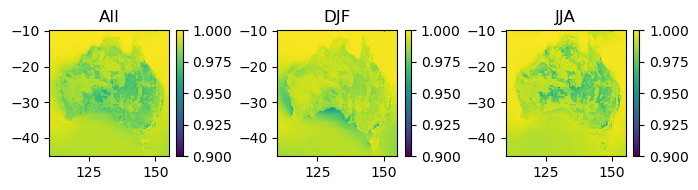

In [43]:
fig, ax = plt.subplots(1, 3, figsize=(7,2))

era5_corr.plot(ax=ax[0], vmin=0.9, vmax=1)
ax[0].set_title("All")

era5_corr_DJF.plot(ax=ax[1], vmin=0.9, vmax=1)
ax[1].set_title("DJF")

era5_corr_JJA.plot(ax=ax[2], vmin=0.9, vmax=1)
ax[2].set_title("JJA")

for a in ax:
    a.set_ylabel("")
    a.set_xlabel("")
plt.tight_layout()

Overlap of drought days

In [83]:
era5_100m_dr = xr.where(
    era5_100m < era5_100m.quantile(0.05, dim="time"),
    1,
    0
).astype("int16")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


In [84]:
era5_10m_dr = xr.where(
    era5_10m < era5_10m.quantile(0.05, dim="time"),
    1,
    0
).astype("int16")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/dask/array/core.py:4998: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(


In [91]:
x = era5_100m_dr + era5_10m_dr

In [95]:
y = (x.where(x == 2).count("time") / len(x["time"])).compute()

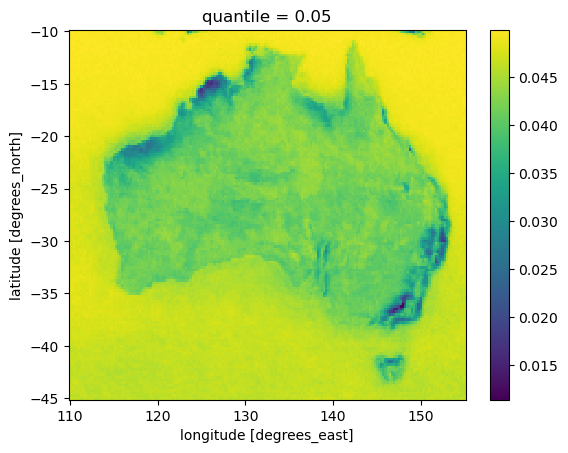

In [96]:
y.plot()

In [94]:
rez_mask = xr.open_dataset(
    '/g/data/w42/dr6273/work/projects/Aus_energy/data/rez_2024_mask_era5_grid.nc'
)["REZ"]

In [103]:
nem_wind = rez_mask.where(rez_mask.region_code_2023.isin([1, 3, 4]))

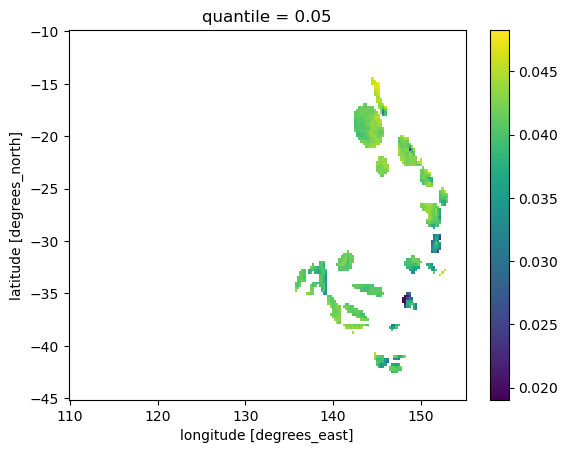

In [102]:
y.where(nem_wind.sum("region")).plot()

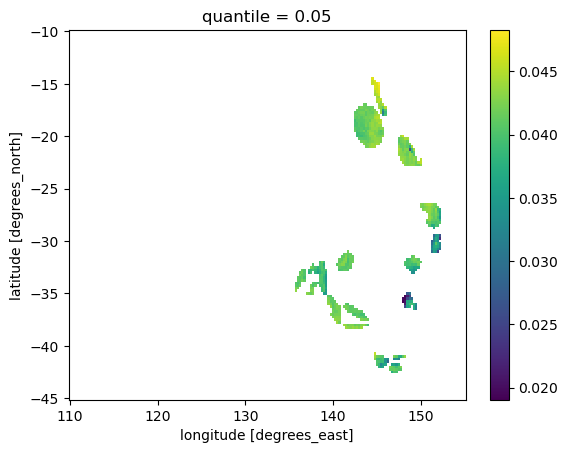

In [104]:
y.where(nem_wind.sum("region")).plot()

In [107]:
rez_mask.where(rez_mask.region_code_SC2050 == 4).dropna("region")

<xarray.DataArray 'REZ' (region: 2, lat: 141, lon: 181)> Size: 408kB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * lat                 (lat) float32 564B -10.0 -10.25 -10.5 ... -44.75 -45.0
  * lon                 (lon) float32 724B 110.0 110.2 110.5 ... 154.8 155.0
  * region              (region) <U3 24B 'N10' 'V8'
    region_code_2023    (region) int64 16B 5 5
    region_code_SC2050  (region) int64 16B 4 4
    latitude            (region) float64 16B -32.99 -38.68
    longitude           (region) float64 16B 152.5 142.3
Attributes:
    standard_name:  region